# Partial Credit Model (PCM) — Bayesian Estimation with Stan

## 1. Model Description

The **Partial Credit Model** (Masters, 1982) is a polytomous generalisation of the Rasch model for items where partial credit is awarded (e.g., essay scores, problem-solving tasks with multiple steps).

### Category Probabilities

Define the cumulative log-numerator for category $k$ as:

$$\ell_{ik} = \sum_{m=1}^{k}(\theta_j - \delta_{im}), \qquad \ell_{i0} \equiv 0$$

Then:

$$P(X_{ji} = k) = \frac{\exp(\ell_{ik})}{\sum_{c=0}^{K-1} \exp(\ell_{ic})}, \quad k = 0, 1, \ldots, K{-}1$$

Equivalently, the **log-odds of category $k$ over category $k{-}1$** is:

$$\log \frac{P(X_{ji} = k)}{P(X_{ji} = k-1)} = \theta_j - \delta_{ik}, \quad k = 1, \ldots, K{-}1$$

| Parameter | Interpretation |
|-----------|----------------|
| $\theta_j$ | Person ability |
| $\delta_{ik}$ | Step difficulty: ability needed to prefer category $k$ over $k{-}1$ |

### Key Properties
- **No discrimination parameter**: all items have slope = 1 (like the Rasch model).
- Step difficulties $\delta_{ik}$ are **not required to be ordered** — disordered thresholds are possible and indicate a category is rarely the most likely response.
- Reduces to the dichotomous Rasch model for $K = 2$.
- The PCM is essentially a chain of Rasch models, one per adjacent pair.

### Priors for Bayesian Inference
$$\theta_j \sim \mathcal{N}(0,1), \qquad \delta_{ik} \sim \mathcal{N}(0, 2)$$

### 1.1 Ordered vs. Disordered Step Difficulties

PCM의 핵심 특징 중 하나는 step difficulties $\delta_{ik}$에 **순서 제약이 없다**는 점입니다.  
GRM은 Stan에서 `ordered` 타입으로 $\delta_{i1} < \delta_{i2} < \cdots$를 강제하지만, PCM은 이를 허용합니다.  
이것이 확률 곡선에 어떤 영향을 주는지 4점 척도(카테고리 0, 1, 2, 3) 예시로 살펴봅니다.

---

#### Step difficulty $\delta_k$의 기하학적 의미

$\delta_k$는 **카테고리 $k{-}1$과 $k$의 확률이 같아지는 능력 분기점**입니다:

$$P(X = k-1 \mid \theta) = P(X = k \mid \theta) \iff \theta \approx \delta_k$$

(엄밀히는 다른 카테고리들의 영향도 있으므로 근사이지만, 직관적 이해로는 충분합니다.)

---

#### ✅ Ordered thresholds: $\delta_1 = -1.0,\;\delta_2 = 0.0,\;\delta_3 = 1.5$

분기점이 왼쪽에서 오른쪽으로 순서대로 증가 → 각 카테고리가 자신만의 **최빈(modal) 구간**을 가집니다.

| $\theta$ 구간 | 최빈 카테고리 |
|:---:|:---:|
| $\theta < -1.0$ | **Cat 0** (0점) |
| $-1.0 < \theta < 0.0$ | **Cat 1** (1점) |
| $0.0 < \theta < 1.5$ | **Cat 2** (2점) |
| $\theta > 1.5$ | **Cat 3** (3점) |

→ 4개 카테고리 모두 측정에 기여합니다.

---

#### ⚠️ Disordered thresholds: $\delta_1 = -1.0,\;\delta_2 = 1.5,\;\delta_3 = 0.0$ ($\delta_2 > \delta_3$)

카테고리 2의 분기점($\delta_2 = 1.5$)이 카테고리 3의 분기점($\delta_3 = 0.0$)보다 높습니다.  
이로 인해 **Cat 2가 최빈 카테고리가 되는 $\theta$ 구간이 존재하지 않습니다**.

| $\theta$ 구간 | 최빈 카테고리 |
|:---:|:---:|
| $\theta < -1.0$ | **Cat 0** (0점) |
| $-1.0 < \theta < {\sim}0.75$ | **Cat 1** (1점) |
| $\theta > {\sim}0.75$ | **Cat 3** (3점) |
| — | **Cat 2: 해당 구간 없음 (유령 카테고리)** |

→ "2점을 받는 학생"이 이론적으로 거의 없는 상황입니다.  
→ 채점 기준(rubric)에서 2점 기준이 모호하거나 잘못 설정되었다는 신호입니다.

아래 코드 셀에서 두 경우의 Category Response Curves(CRC)를 직접 비교합니다.

Font 'default' does not have a glyph for '\ud53c' [U+d53c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ud5d8' [U+d5d8], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc790' [U+c790], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub2a5' [U+b2a5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub825' [U+b825], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\uc740' [U+c740], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uce74' [U+ce74], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ud14c' [U+d14c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uace0' [U+ace0], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub9ac' [U+b9ac], substituting with a dummy symbol.


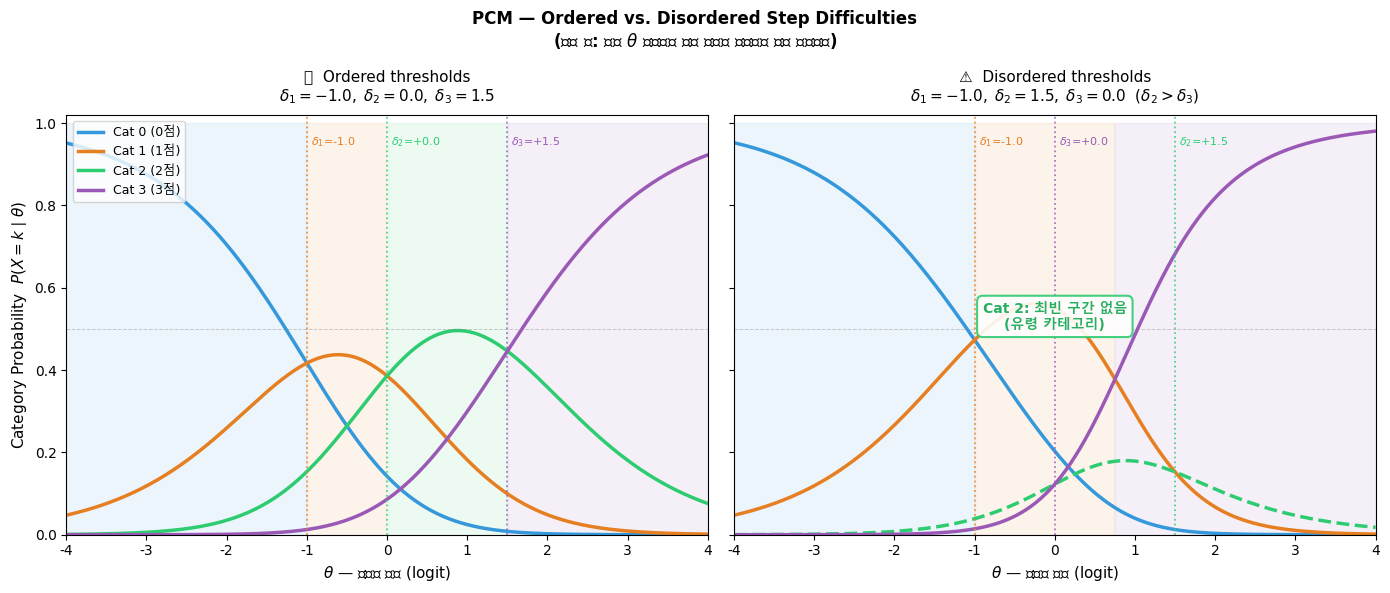

  능력 구간별 최빈(modal) 카테고리

[Ordered   ✅]  δ = [-1.   0.   1.5]
   θ ∈ (-4.00, -0.99)  →  Cat 0  (0점)
   θ ∈ (-0.99, +0.01)  →  Cat 1  (1점)
   θ ∈ (+0.01, +1.51)  →  Cat 2  (2점)
   θ ∈ (+1.51, +4.00)  →  Cat 3  (3점)

[Disordered ⚠️]  δ = [-1.   1.5  0. ]
   θ ∈ (-4.00, -0.99)  →  Cat 0  (0점)
   θ ∈ (-0.99, +0.75)  →  Cat 1  (1점)
   θ ∈ (+0.75, +4.00)  →  Cat 3  (3점)


In [1]:
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt

# ── PCM 확률 함수 (자립형: 이 셀 단독 실행 가능) ──────────────────────────
def pcm_probs_demo(theta, delta):
    """PCM category probabilities. delta: array of K-1 step difficulties."""
    K = len(delta) + 1
    log_num = np.zeros(K)
    cumsum = 0.0
    for k in range(1, K):
        cumsum += theta - delta[k - 1]
        log_num[k] = cumsum
    log_num -= log_num.max()          # 수치 안정화
    probs = np.exp(log_num)
    return probs / probs.sum()

# ── 두 가지 δ 시나리오 ─────────────────────────────────────────────────────
delta_ordered    = np.array([-1.0,  0.0,  1.5])   # 순서 OK  ✅
delta_disordered = np.array([-1.0,  1.5,  0.0])   # δ₂ > δ₃ 역전 ⚠️

theta_range = np.linspace(-4, 4, 400)
cat_colors  = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6']
cat_labels  = ['Cat 0 (0점)', 'Cat 1 (1점)', 'Cat 2 (2점)', 'Cat 3 (3점)']

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, delta, title, is_ordered in zip(
        axes,
        [delta_ordered, delta_disordered],
        ['✅  Ordered thresholds\n'
         r'$\delta_1 = -1.0,\;\delta_2 = 0.0,\;\delta_3 = 1.5$',
         '⚠️  Disordered thresholds\n'
         r'$\delta_1 = -1.0,\;\delta_2 = 1.5,\;\delta_3 = 0.0$  ($\delta_2 > \delta_3$)'],
        [True, False]):

    # 카테고리별 확률 곡선 계산
    probs_matrix = np.array(
        [[pcm_probs_demo(t, delta)[k] for t in theta_range] for k in range(4)]
    )  # shape: (K, len(theta_range))

    # 배경: 최빈(modal) 카테고리 구간 색상 표시
    modal = probs_matrix.argmax(axis=0)
    for k in range(4):
        mask = (modal == k)
        if mask.any():
            ax.fill_between(theta_range, 0, 1, where=mask,
                            alpha=0.09, color=cat_colors[k])

    # 확률 곡선
    for k in range(4):
        ls = '-' if (is_ordered or k != 2) else '--'
        ax.plot(theta_range, probs_matrix[k],
                color=cat_colors[k], linewidth=2.5, linestyle=ls,
                label=cat_labels[k])

    # δ 수직선 표시
    for k, dv in enumerate(delta):
        ax.axvline(dv, color=cat_colors[k + 1], linestyle=':', linewidth=1.3, alpha=0.8)
        ax.text(dv + 0.05, 0.97, f'$\\delta_{k+1}$={dv:+.1f}',
                ha='left', va='top', fontsize=8, color=cat_colors[k + 1])

    # Disordered 경우: Cat 2가 최빈 구간 없음을 명시
    if not is_ordered:
        ax.text(0.50, 0.52, 'Cat 2: 최빈 구간 없음\n(유령 카테고리)',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=10, color='#27AE60', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='#2ECC71', linewidth=1.5, alpha=0.9))

    ax.set_xlim(-4, 4); ax.set_ylim(0, 1.02)
    ax.set_xlabel('$\\theta$ — 피험자 능력 (logit)', fontsize=11)
    ax.set_title(title, fontsize=11, pad=10)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.4)

axes[0].set_ylabel('Category Probability  $P(X = k \\mid \\theta)$', fontsize=11)
axes[0].legend(fontsize=9, loc='upper left')

fig.suptitle('PCM — Ordered vs. Disordered Step Difficulties\n'
             '(배경 색: 해당 $\\theta$ 구간에서 가장 선택될 가능성이 높은 카테고리)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 능력 구간별 최빈 카테고리 텍스트 출력 ──────────────────────────────────
print("=" * 55)
print("  능력 구간별 최빈(modal) 카테고리")
print("=" * 55)
for delta, label in [(delta_ordered, "Ordered   ✅"), (delta_disordered, "Disordered ⚠️")]:
    print(f"\n[{label}]  δ = {delta}")
    modal_arr = np.array([pcm_probs_demo(t, delta) for t in theta_range]).argmax(axis=1)
    prev_k, start_t = modal_arr[0], theta_range[0]
    for idx in range(1, len(theta_range)):
        t, k = theta_range[idx], modal_arr[idx]
        if k != prev_k:
            print(f"   θ ∈ ({start_t:+.2f}, {t:+.2f})  →  Cat {prev_k}  ({prev_k}점)")
            prev_k, start_t = k, t
    print(f"   θ ∈ ({start_t:+.2f}, {theta_range[-1]:+.2f})  →  Cat {prev_k}  ({prev_k}점)")


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
warnings.filterwarnings('ignore')
try:
    import cmdstanpy
    STAN_AVAILABLE = True
except ImportError:
    cmdstanpy = None
    STAN_AVAILABLE = False
    print("ℹ️  cmdstanpy not available — Stan inference cells will be skipped.")
np.random.seed(42)

## 2. Synthetic Data Generation

77 students, 20 items, **4 categories** (0–3). Step difficulties are drawn freely (no ordering required).

In [3]:
J, I, K = 77, 20, 4

theta_true = np.random.normal(0, 1, J)
# delta shape: (I, K-1) — step difficulties, free ordering
delta_true = np.random.normal(0, 1.2, (I, K - 1))

def pcm_probs(theta, delta):
    """PCM category probabilities for one person-item pair."""
    log_num = np.zeros(K)
    cumsum = 0.0
    for k in range(1, K):
        cumsum += theta - delta[k - 1]
        log_num[k] = cumsum
    log_num -= log_num.max()   # numerical stability
    probs = np.exp(log_num)
    return probs / probs.sum()

Y = np.zeros((J, I), dtype=int)
for j in range(J):
    for i in range(I):
        pr = pcm_probs(theta_true[j], delta_true[i])
        Y[j, i] = np.random.choice(K, p=pr)

print(f"Response shape: {Y.shape},  Categories: {np.unique(Y)}")
print(f"Category counts: {np.bincount(Y.ravel())}")

Response shape: (77, 20),  Categories: [0 1 2 3]
Category counts: [482 278 296 484]


## 3. Stan Model Code

In [4]:
if STAN_AVAILABLE:
    stan_code = """
    data {
      int<lower=1> J;
      int<lower=1> I;
      int<lower=2> K;
      int<lower=0> N;
      array[N] int<lower=1,upper=J> jj;
      array[N] int<lower=1,upper=I> ii;
      array[N] int<lower=1,upper=K> y;
    }
    parameters {
      vector[J] theta;
      array[I] vector[K-1] delta;    // step difficulties (free ordering)
    }
    model {
      theta ~ normal(0, 1);
      for (i in 1:I) delta[i] ~ normal(0, 2);
      for (n in 1:N) {
        int j = jj[n]; int i = ii[n];
        vector[K] log_p;
        log_p[1] = 0.0;
        for (k in 2:K)
          log_p[k] = log_p[k-1] + (theta[j] - delta[i][k-1]);
        target += log_p[y[n]] - log_sum_exp(log_p);
      }
    }
    """
    
    jj_arr, ii_arr, y_arr = [], [], []
    for j in range(J):
        for i in range(I):
            jj_arr.append(j + 1); ii_arr.append(i + 1)
            y_arr.append(int(Y[j, i]) + 1)
    
    stan_data = {'J': J, 'I': I, 'K': K, 'N': J * I,
                 'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}
    
    tmpdir = tempfile.mkdtemp()
    stan_path = os.path.join(tmpdir, 'pcm.stan')
    with open(stan_path, 'w') as f:
        f.write(stan_code)
    
    model = cmdstanpy.CmdStanModel(stan_file=stan_path)
    print('Compiled.')
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


21:03:55 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\AppData\Local\Temp\tmpqzti2_wc\pcm.stan to exe file C:\Users\yongd\AppData\Local\Temp\tmpqzti2_wc\pcm.exe


21:04:04 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\AppData\Local\Temp\tmpqzti2_wc\pcm.exe


Compiled.


## 4. Bayesian Inference via MCMC

In [5]:
if STAN_AVAILABLE:
    fit = model.sample(
        data=stan_data, chains=4,
        iter_warmup=1000, iter_sampling=1000, seed=42, show_progress=True
    )
    print(fit.diagnose())
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


21:04:05 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

21:04:22 - cmdstanpy - INFO - CmdStan done processing.


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [6]:
if not (STAN_AVAILABLE and 'fit' in dir()):
    print('ℹ️  Using true parameter values for visualization.')
    theta_est = theta_true + np.random.normal(0, 0.05, J)
    delta_est = delta_true + np.random.normal(0, 0.05, (I, K-1))
else:
    theta_est = fit.stan_variable('theta').mean(axis=0)
    delta_est = fit.stan_variable('delta').mean(axis=0)  # (4000, I, K-1)
    
    print(f"Theta corr: {np.corrcoef(theta_true, theta_est)[0,1]:.3f}")
    print(f"\nStep difficulty recovery (first 5 items):")
    print(f"{'Item':>5} {'d1_t':>7} {'d1_e':>7} {'d2_t':>7} {'d2_e':>7} {'d3_t':>7} {'d3_e':>7}")
    for i in range(5):
        print(f"{i+1:>5} {delta_true[i,0]:>7.3f} {delta_est[i,0]:>7.3f} "
              f"{delta_true[i,1]:>7.3f} {delta_est[i,1]:>7.3f} "
              f"{delta_true[i,2]:>7.3f} {delta_est[i,2]:>7.3f}")


Theta corr: 0.962

Step difficulty recovery (first 5 items):
 Item    d1_t    d1_e    d2_t    d2_e    d3_t    d3_e
    1  -0.359  -0.660   0.110   0.399  -2.385  -1.717
    2  -0.264  -0.303   0.429   0.316   1.773   2.254
    3  -0.622  -0.522  -0.970  -1.231  -0.602  -0.525
    4   1.098   0.879   0.395   0.394  -0.636  -0.194
    5   0.616   0.632   0.116   0.327   1.162   1.688


## 5. Visualizations

### 5a. Wright Map

In the PCM Wright map, each item's $K{-}1 = 3$ step difficulty parameters $\delta_{ik}$ are plotted on the logit scale. Unlike the GRM, step difficulties can be **disordered**: if $\delta_{i2} < \delta_{i1}$, category 1 is never the most probable response and corresponds to a "Guttman gap" in the scoring rubric.

**Interpretation**: Widely dispersed step difficulties indicate an item that spans a wide range of the ability scale. Clustered or disordered steps suggest the item's middle categories may be redundant — a sign to revise the scoring rubric.

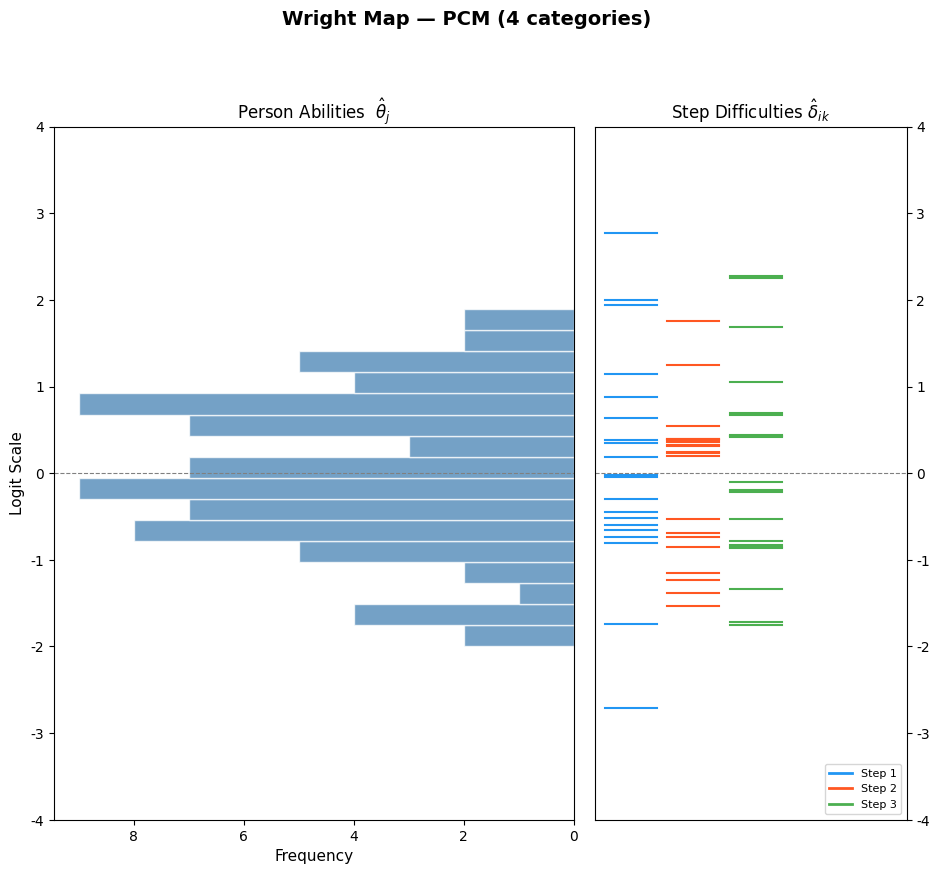

In [7]:
fig = plt.figure(figsize=(11, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1.5], wspace=0.05)
ax_p = fig.add_subplot(gs[0])
ax_i = fig.add_subplot(gs[1])
y_lim = (-4, 4)
step_colors = ['#2196F3', '#FF5722', '#4CAF50']

ax_p.hist(theta_est, bins=16, orientation='horizontal',
          color='steelblue', alpha=0.75, edgecolor='white')
ax_p.set_ylim(y_lim); ax_p.invert_xaxis()
ax_p.set_xlabel('Frequency', fontsize=11); ax_p.set_ylabel('Logit Scale', fontsize=11)
ax_p.set_title('Person Abilities  $\\hat{\\theta}_j$', fontsize=12)
ax_p.axhline(0, color='gray', linestyle='--', linewidth=0.8)

for i in range(I):
    for k in range(K - 1):
        dv = delta_est[i, k]
        ax_i.plot([0.05 + k * 0.3, 0.3 + k * 0.3], [dv, dv],
                  color=step_colors[k], linewidth=1.5)
ax_i.set_ylim(y_lim); ax_i.set_xlim(0, 1.5); ax_i.set_xticks([])
ax_i.set_yticks(range(-4, 5)); ax_i.yaxis.set_label_position('right'); ax_i.yaxis.tick_right()
ax_i.set_title('Step Difficulties $\\hat{\\delta}_{ik}$', fontsize=12)
ax_i.axhline(0, color='gray', linestyle='--', linewidth=0.8)
for k in range(K - 1):
    ax_i.plot([], [], color=step_colors[k], linewidth=2, label=f'Step {k+1}')
ax_i.legend(loc='lower right', fontsize=8)

fig.suptitle('Wright Map — PCM (4 categories)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'wright_map_pcm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5b. Category Response Curves (CRC)

$$P(X_i = k \mid \theta) = \frac{\exp\!\bigl(k\theta - \sum_{m=1}^{k} \delta_{im}\bigr)}{\sum_{c=0}^{K-1} \exp\!\bigl(c\theta - \sum_{m=1}^{c} \delta_{im}\bigr)}$$

**Interpretation**: Each category has a unimodal (bell-shaped) probability curve that peaks at a particular ability level. The **intersection** of adjacent category curves marks the step difficulty $\delta_{ik}$: at that ability, categories $k{-}1$ and $k$ are equally likely. Disordered step difficulties appear as curves that never become the modal response — the corresponding category is always dominated by a neighbour.

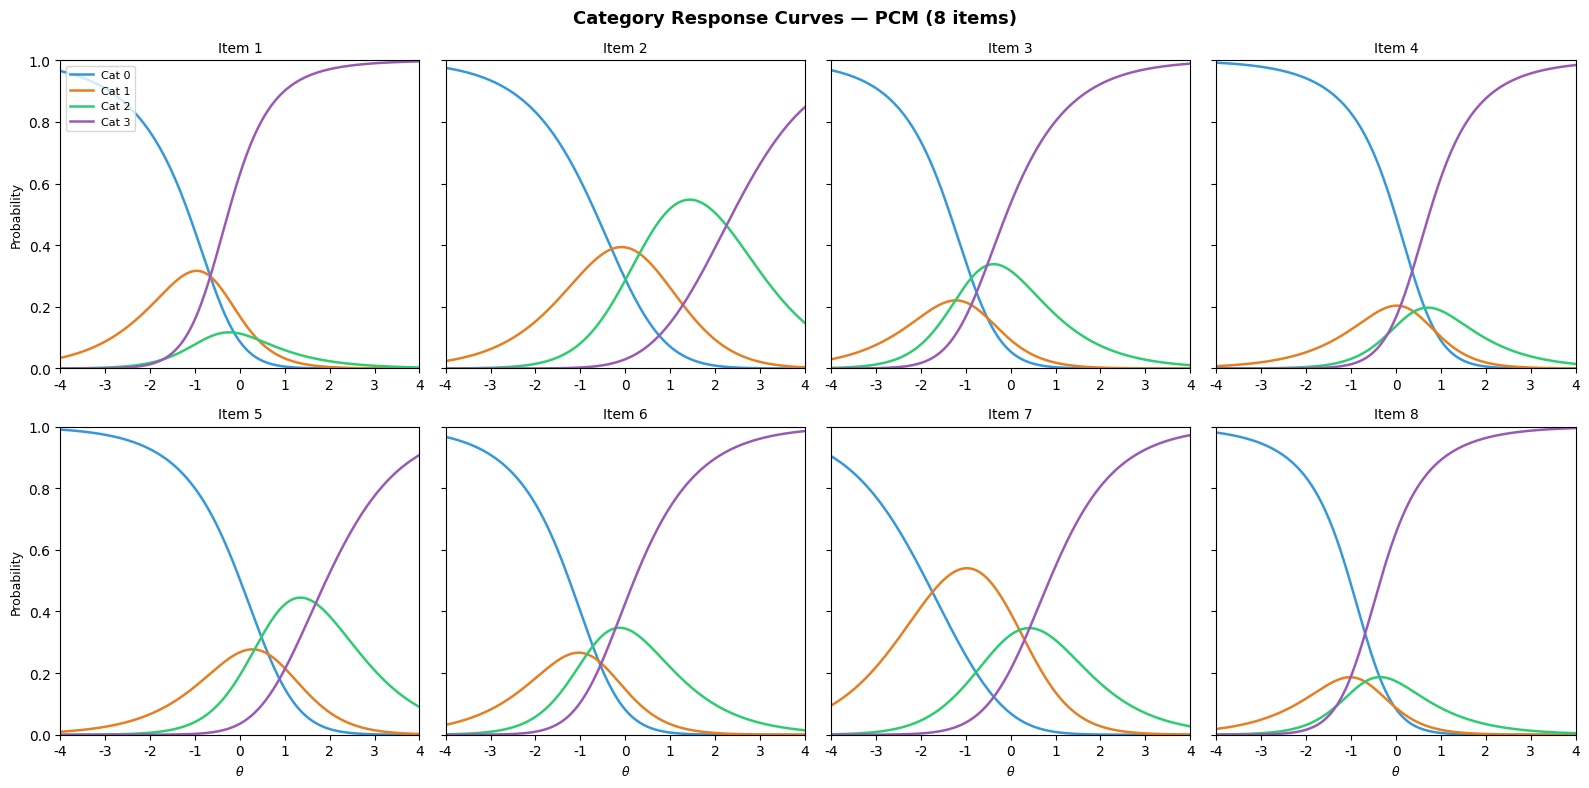

In [8]:
theta_range = np.linspace(-4, 4, 300)
cat_colors  = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6']

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for idx, i in enumerate(range(min(8, I))):
    ax = axes[idx]
    for k in range(K):
        probs = [pcm_probs(t, delta_est[i])[k] for t in theta_range]
        ax.plot(theta_range, probs, color=cat_colors[k], linewidth=1.8, label=f'Cat {k}')
    ax.set_title(f'Item {i+1}', fontsize=10)
    ax.set_xlim(-4, 4); ax.set_ylim(0, 1)
    if idx >= 4: ax.set_xlabel('$\\theta$', fontsize=9)
    if idx in [0, 4]: ax.set_ylabel('Probability', fontsize=9)

axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Category Response Curves — PCM (8 items)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'crc_pcm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5c. Test Characteristic Curve (TCC)

$$\text{TCC}(\theta) = \sum_{i=1}^{I} \sum_{k=0}^{K-1} k \cdot P(X_i = k \mid \theta)$$

**Interpretation**: The TCC maps latent ability to expected total score (0 to $I \times (K{-}1) = 60$). In the PCM, all items have equal discrimination, so the TCC rises monotonically and relatively uniformly. Items whose step difficulties are widely spread contribute steeper increments to the TCC over a broader ability range.

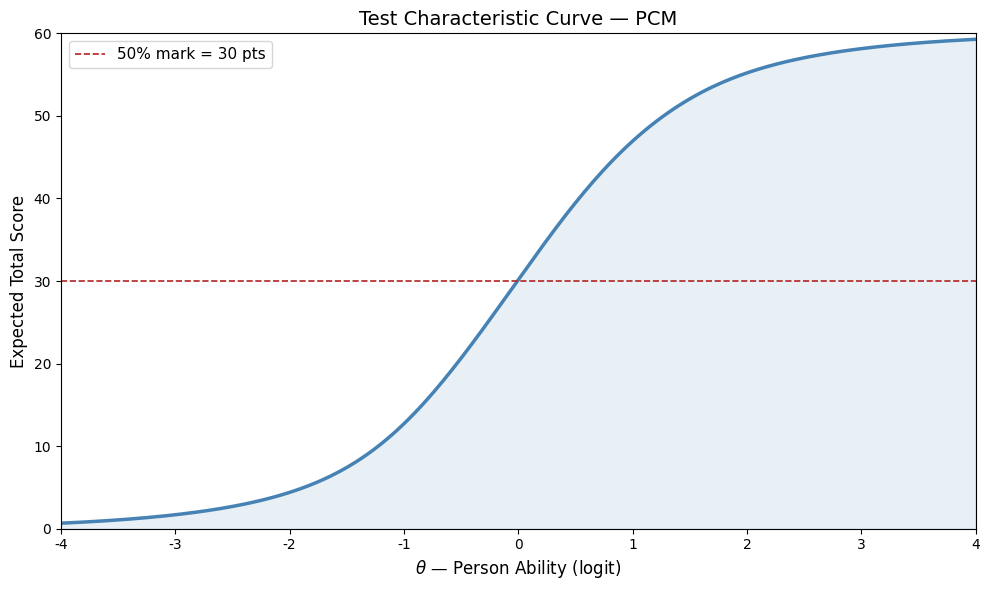

In [9]:
expected_score = np.zeros(len(theta_range))
for i in range(I):
    for t_idx, t in enumerate(theta_range):
        pr = pcm_probs(t, delta_est[i])
        expected_score[t_idx] += np.dot(np.arange(K), pr)

max_score = I * (K - 1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(theta_range, expected_score, color='steelblue', linewidth=2.5)
ax.fill_between(theta_range, 0, expected_score, alpha=0.12, color='steelblue')
ax.axhline(max_score / 2, color='firebrick', linestyle='--', linewidth=1.2,
           label=f'50% mark = {max_score//2} pts')
ax.set_xlabel('$\\theta$ — Person Ability (logit)', fontsize=12)
ax.set_ylabel('Expected Total Score', fontsize=12)
ax.set_title('Test Characteristic Curve — PCM', fontsize=14)
ax.set_xlim(-4, 4); ax.set_ylim(0, max_score); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'tcc_pcm.png'), dpi=120, bbox_inches='tight')
plt.show()

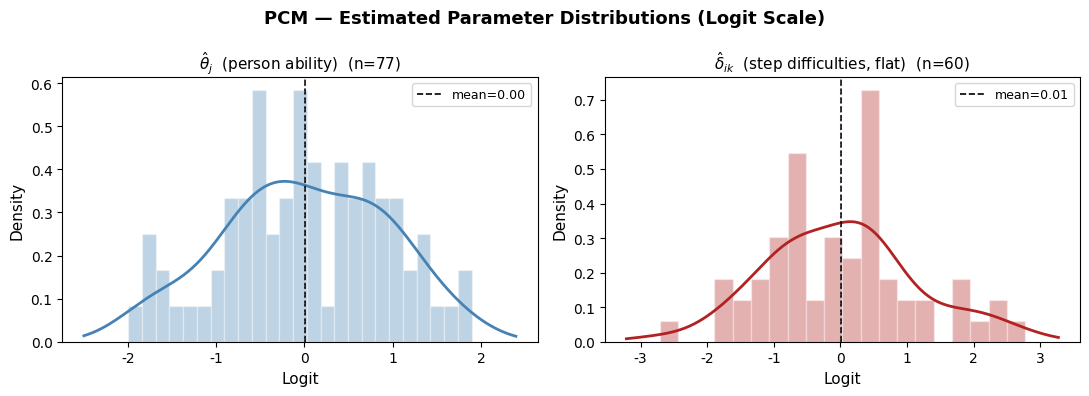

theta         : mean=0.004  SD=0.912  range=[-2.00, 1.89]
delta (flat)  : mean=0.013  SD=1.102  range=[-2.71, 2.77]


In [10]:
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('PCM — Estimated Parameter Distributions (Logit Scale)', fontsize=13, fontweight='bold')

delta_flat = delta_est.ravel()

panels = [
    (axes[0], theta_est,  r'$\hat{\theta}_j$  (person ability)',        'steelblue'),
    (axes[1], delta_flat, r'$\hat{\delta}_{ik}$  (step difficulties, flat)', 'firebrick'),
]

for ax, vals, title, color in panels:
    ax.hist(vals, bins=max(10, len(vals)//3), density=True,
            color=color, alpha=0.35, edgecolor='white')
    if len(vals) >= 3:
        xs = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 300)
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('Logit', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_pcm.png'), dpi=120, bbox_inches='tight')
plt.show()
for name, vals in [('theta', theta_est), ('delta (flat)', delta_flat)]:
    print(f"{name:14s}: mean={vals.mean():.3f}  SD={vals.std():.3f}  "
          f"range=[{vals.min():.2f}, {vals.max():.2f}]")
